<a href="https://colab.research.google.com/github/YevheniiaMalchenko/ML/blob/main/%D0%9B%D0%914_%D0%9C%D0%B0%D0%BB%D1%8C%D1%87%D0%B5%D0%BD%D0%BA%D0%BE_3_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лабораторна робота №4. Регресійні моделі: глибоке дослідження

**Датасет:** Car Price Prediction Multiple Linear Regression  
https://www.kaggle.com/datasets/hellbuoy/car-price-prediction?select=CarPrice_Assignment.csv

**Мета роботи:** виконати підготовку даних, побудувати та порівняти регресійні моделі для прогнозування ціни автомобіля, оцінити їх якість і проаналізувати отримані результати.

> У шаблоні наведено лише умови завдань. Реалізацію необхідно виконати самостійно у порожніх комірках.


## 1. Завантаження та первинний аналіз даних

Завантажити датасет та виконати його первинний огляд:
- визначити кількість об'єктів і ознак;
- переглянути назви стовпців;
- визначити типи даних;
- визначити цільову змінну;
- вивести основні статистичні характеристики даних.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving CarPrice_Assignment.csv to CarPrice_Assignment (1).csv


In [ ]:
df = pd.read_csv('CarPrice_Assignment.csv')
display(df)

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,201,-1,volvo 145e (sw),gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845.0
201,202,-1,volvo 144ea,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045.0
202,203,-1,volvo 244dl,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485.0
203,204,-1,volvo 246,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470.0


In [ ]:
#визначити кількість об'єктів і ознак;
print(f"К-ть об'єктів: {df.shape[0]}")
print(f"К-ть ознак: {df.shape[1]}")

К-ть об'єктів: 205
К-ть ознак: 26


In [ ]:
#переглянути назви стовпців;
df.columns.tolist()

['car_ID',
 'symboling',
 'CarName',
 'fueltype',
 'aspiration',
 'doornumber',
 'carbody',
 'drivewheel',
 'enginelocation',
 'wheelbase',
 'carlength',
 'carwidth',
 'carheight',
 'curbweight',
 'enginetype',
 'cylindernumber',
 'enginesize',
 'fuelsystem',
 'boreratio',
 'stroke',
 'compressionratio',
 'horsepower',
 'peakrpm',
 'citympg',
 'highwaympg',
 'price']

In [ ]:
#визначити типи даних;
df.dtypes

,0
car_ID,int64
symboling,int64
CarName,object
fueltype,object
aspiration,object
doornumber,object
carbody,object
drivewheel,object
enginelocation,object
wheelbase,float64


In [ ]:
#вивести основні статистичні характеристики даних.
df.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [ ]:
# первинний огляд
df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [1]:
#- визначити цільову змінну;

print("Цільова змінна: price")

Цільова змінна: price


In [ ]:
print(df.columns.tolist())

['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg', 'price']


## 2. Перевірка якості даних

Перевірити:
- наявність пропущених значень;
- наявність повних дублікатів;
- кількість унікальних значень в ознаках.

Під час аналізу врахувати, що `car_ID` є унікальним ідентифікатором автомобіля і сам по собі не повинен використовуватися для визначення дублікатів за змістовими характеристиками.


In [ ]:
# наявність пропущених значень;
df.isnull().sum()

,0
car_ID,0
symboling,0
CarName,0
fueltype,0
aspiration,0
doornumber,0
carbody,0
drivewheel,0
enginelocation,0
wheelbase,0


In [ ]:
# наявність повних дублікатів;
if 'car_ID' in df.columns:
    duplicates_count = df.drop(columns=['car_ID']).duplicated().sum()
else:
    duplicates_count = df.duplicated().sum()

print(f"К-ть повних дублікатів : {duplicates_count}")

К-ть повних дублікатів : 0


In [ ]:
# кількість унікальних значень в ознаках.

display(df.nunique())

,0
car_ID,205
symboling,6
CarName,147
fueltype,2
aspiration,2
doornumber,2
carbody,5
drivewheel,3
enginelocation,2
wheelbase,53


## 3. Робота з car_ID

Зберегти `car_ID` окремо для подальшої ідентифікації автомобілів у результатах прогнозування.  
Не використовувати `car_ID` як ознаку під час навчання моделей.


In [ ]:
if 'car_ID' in df.columns:
    car_ids = df['car_ID'].copy()
    df = df.drop(columns=['car_ID'])
    # перевірим розмірність після видалення колонки
print(f"Новий DataFrame: {df.shape}")

Новий DataFrame: (205, 25)


## 4. Дослідження розподілів числових ознак

Дослідити розподіли числових ознак:
- побудувати відповідні графіки;
- обчислити коефіцієнти асиметрії;
- визначити ознаки з найбільш вираженою асиметрією;
- коротко прокоментувати отримані результати.


Коефіцієнти асиметрії числових ознак:


,0
compressionratio,2.610862
enginesize,1.947655
price,1.777678
horsepower,1.405310
wheelbase,1.050214
carwidth,0.904003
curbweight,0.681398
citympg,0.663704
highwaympg,0.539997
symboling,0.211072


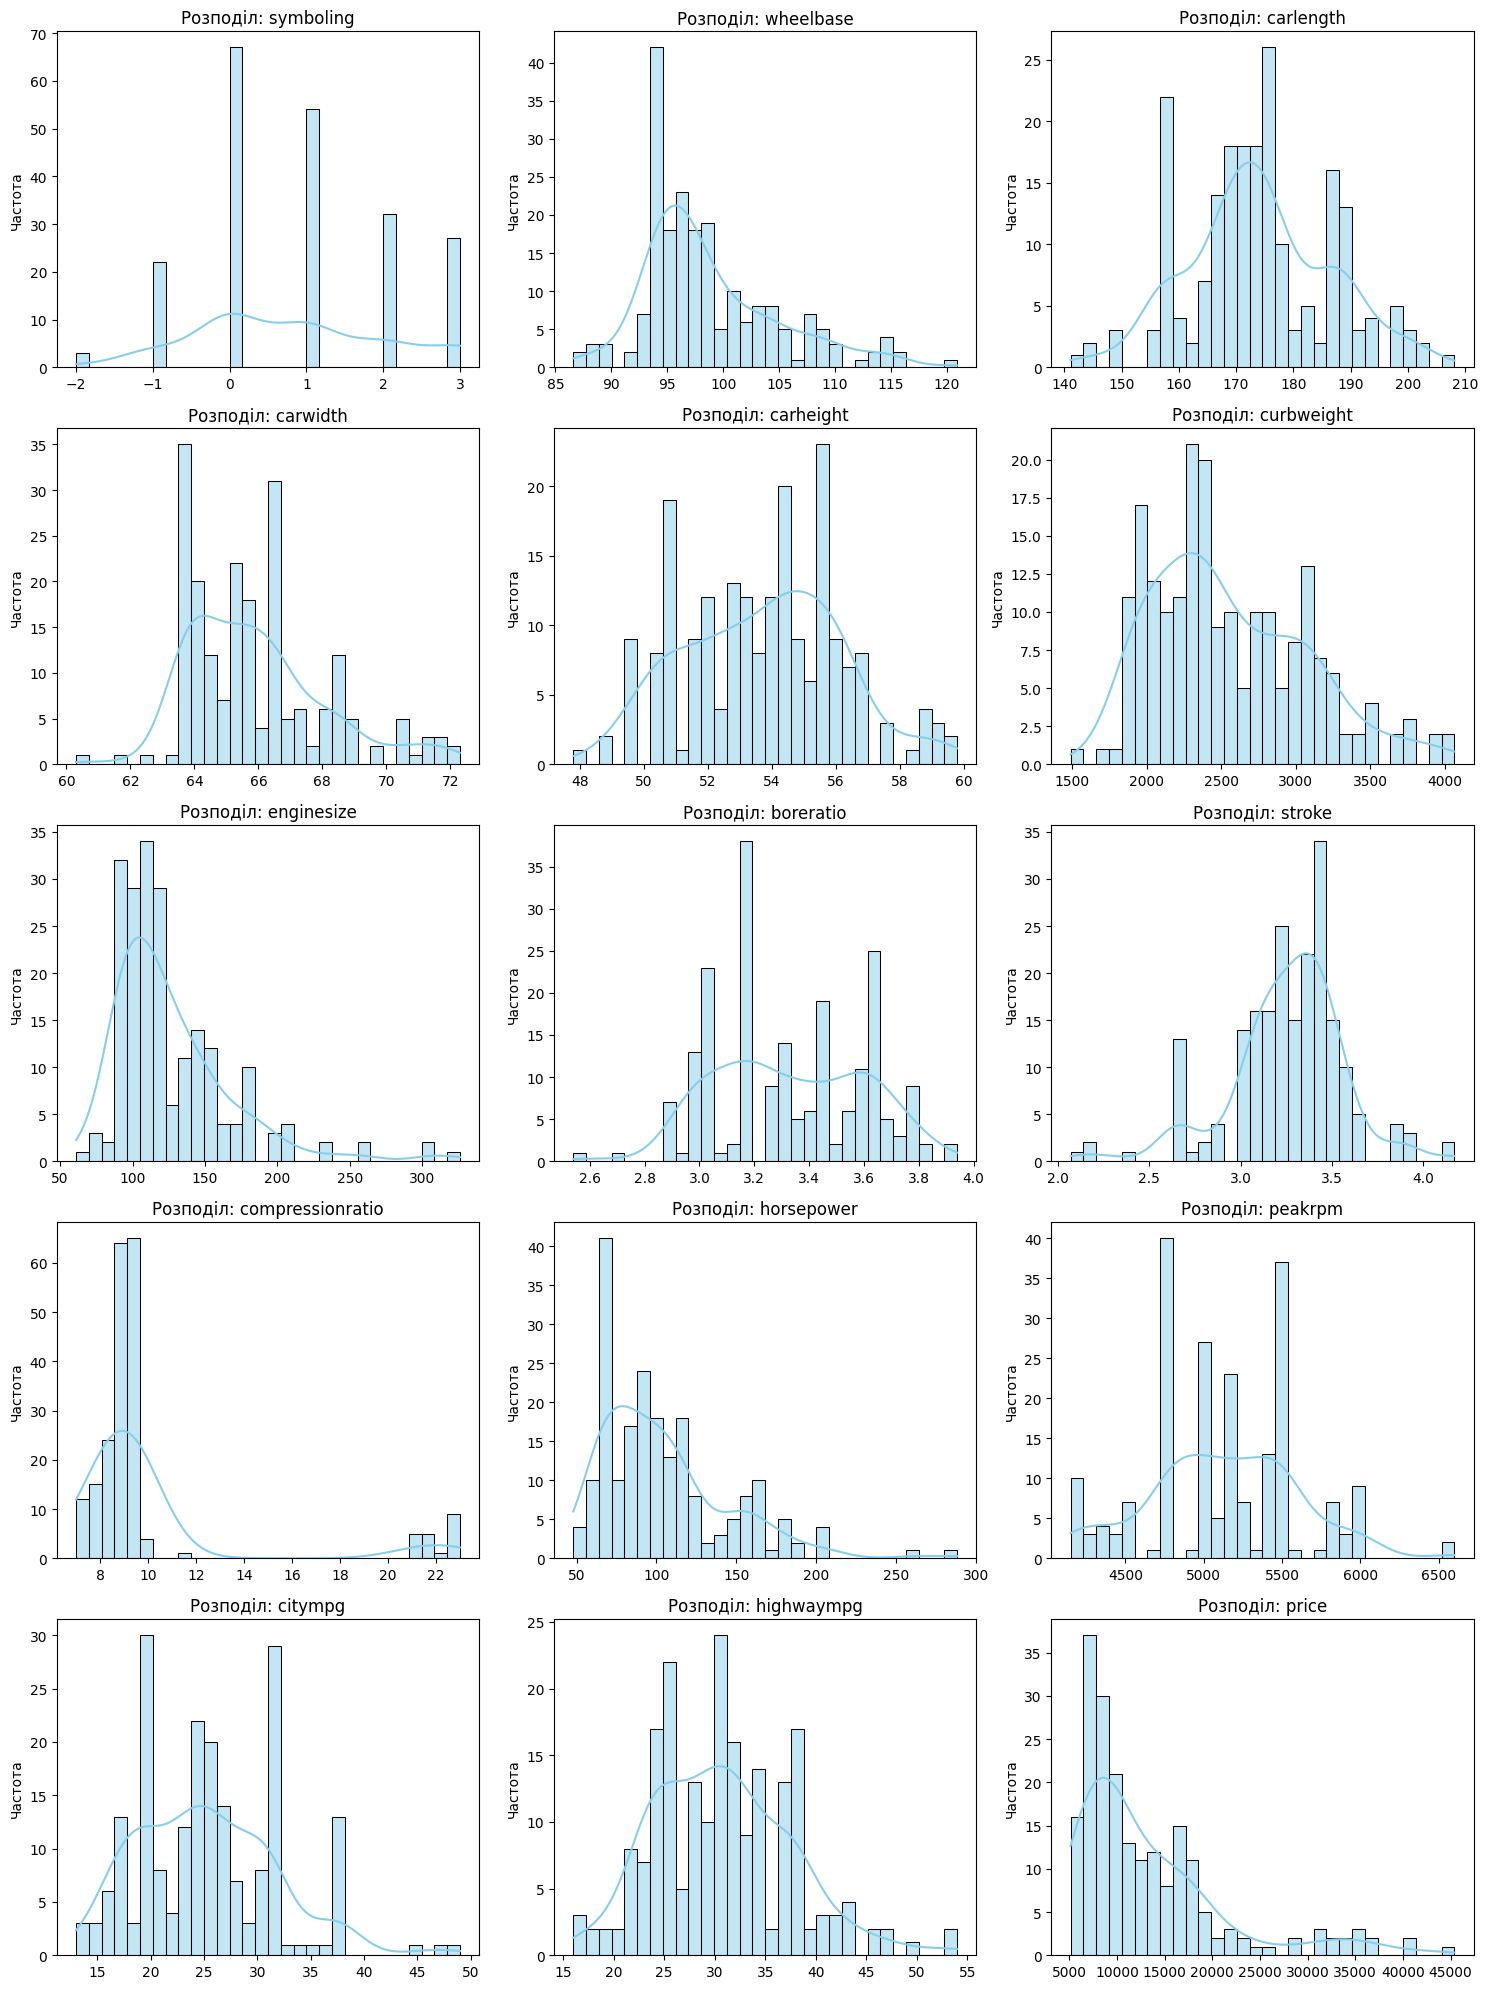

In [ ]:

numeric_cols = df.select_dtypes(include=[np.number]).columns

#  коефіцієнти асиметрії
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("Коефіцієнти асиметрії числових ознак:")
display(skewness)

# графіки
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 4))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Розподіл: {col}')
    plt.xlabel('')
    plt.ylabel('Частота')

plt.tight_layout()
plt.show()

Аналіз коефіцієнтів асиметрії показав, що більшість числових ознак мають правосторонню асиметрію різного ступеня вираженості. Найбільш виражена асиметрія спостерігається у compressionratio (2.61), enginesize (1.95), price (1.78) та horsepower (1.41), тоді як carlength, peakrpm, carheight і boreratio практично симетричні.

## 5. Формування train/test вибірок

Відокремити цільову змінну `price` від ознак та розділити дані на:
- навчальну вибірку — 80%;
- тестову вибірку — 20%.

Забезпечити відтворюваність поділу.  
Окремо зберегти `car_ID` для об'єктів, які потрапили до train і test.

**Важливо:** усі подальші параметри передобробки даних визначати тільки за навчальною вибіркою.


In [ ]:
from sklearn.model_selection import train_test_split
target_col = 'price'

X = df.drop(columns=[target_col])
y = df[target_col]

X_train, X_test, y_train, y_test, ids_train, ids_test = train_test_split(
    X, y, car_ids,
    test_size=0.2,
    random_state=42
)

print(f"Розмір X_train: {X_train.shape}")
print(f"Розмір X_test:  {X_test.shape}")
print(f"Розмір y_train: {y_train.shape}")
print(f"Розмір y_test:  {y_test.shape}")


Розмір X_train: (164, 24)
Розмір X_test:  (41, 24)
Розмір y_train: (164,)
Розмір y_test:  (41,)


## 6. Аналіз та обробка викидів

Для неперервних числових ознак навчальної вибірки:
- визначити потенційні викиди методом IQR;
- вивести кількість потенційних викидів для кожної ознаки;
- обґрунтувати спосіб їх обробки.

Для невеликого набору даних не видаляти автоматично всі рядки з викидами. Використати обмеження крайніх значень межами, визначеними за навчальною вибіркою.

Цільову змінну `price` не використовувати для визначення меж викидів.  
До тестової вибірки застосувати ті самі межі, які були отримані за train.


In [ ]:
# Неперервні числові ознаки
continuous_cols = [col for col in X_train.select_dtypes(include=[np.number]).columns
                   if col != 'symboling']

# Межі IQR  за train
Q1 = X_train[continuous_cols].quantile(0.25)
Q3 = X_train[continuous_cols].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# К-ть викидів у train
outliers = ((X_train[continuous_cols] < lower) |
            (X_train[continuous_cols] > upper)).sum()
print("К-ть викидів у train:")
print(outliers.sort_values(ascending=False))

# Обмеження
X_train[continuous_cols] = X_train[continuous_cols].clip(lower, upper, axis=1)
X_test[continuous_cols]  = X_test[continuous_cols].clip(lower, upper, axis=1)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

К-ть викидів у train:
compressionratio    20
stroke              16
carwidth            10
horsepower           7
enginesize           7
wheelbase            6
peakrpm              2
highwaympg           1
boreratio            1
curbweight           0
carheight            0
carlength            0
citympg              0
dtype: int64
X_train: (164, 24), X_test: (41, 24)


Оскільки вибірка невелика (164 об'єкти в train), автоматичне видалення рядків із викидами призвело б до суттєвої втрати даних і втрати інформативних рідкісних випадків, наприклад дорогі та потужні авто. Тому застосовано обмеження clipping крайніх значень межами IQR, розрахованими тільки за train і застосованими також до test.

## 7. Аналіз кореляцій та відбір ознак

За навчальною вибіркою:
- побудувати матрицю кореляцій числових ознак;
- знайти пари ознак із сильною кореляцією, для яких `|r| > 0.85`;
- для кожної такої пари залишити одну ознаку;
- під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною `price`;
- вивести список сильно корельованих пар та перелік ознак, які видаляються.

Із тестової вибірки видалити ті самі ознаки.  
Не використовувати тестову вибірку для прийняття рішення про відбір ознак.


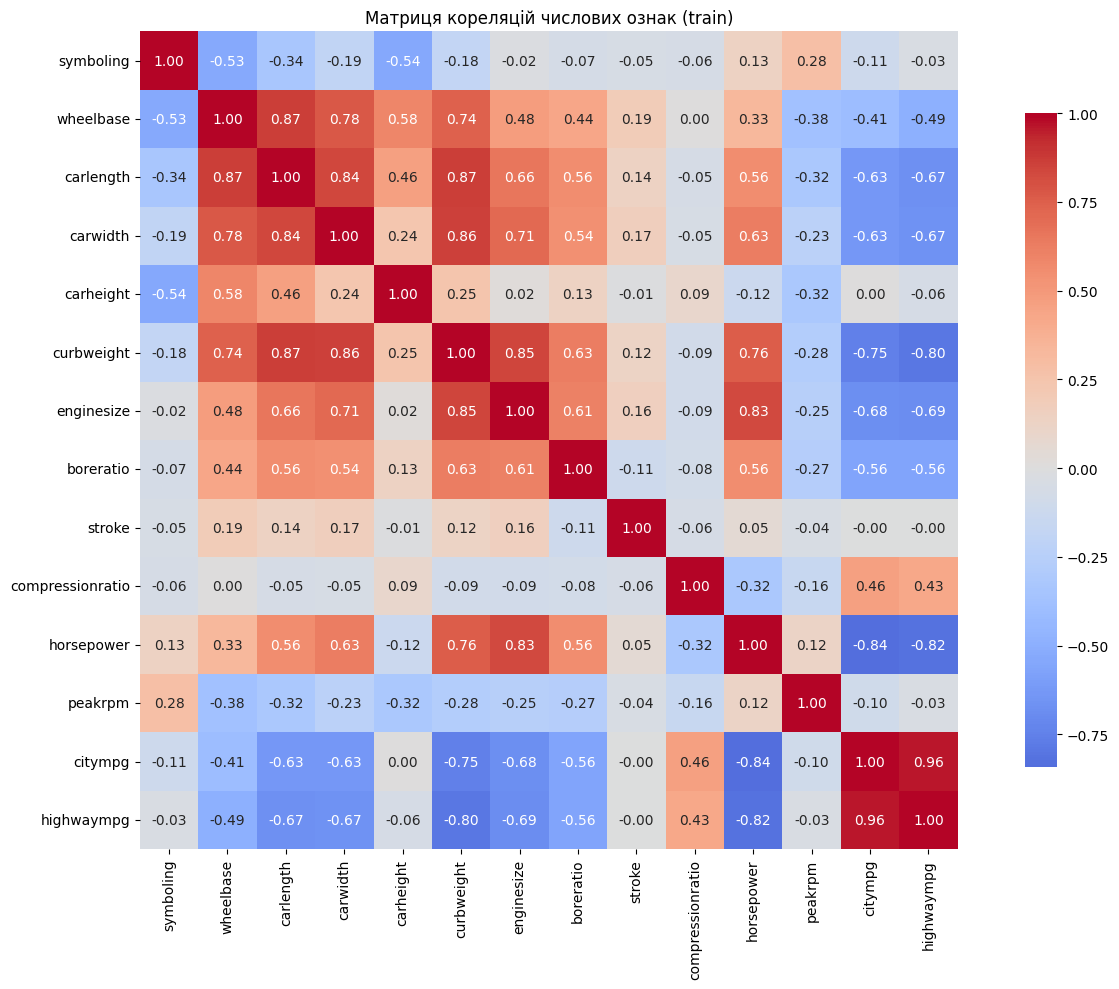

In [ ]:
# побудувати матрицю кореляцій числових ознак;
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

corr_matrix = X_train[num_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, cbar_kws={'shrink': 0.8})
plt.title('Матриця кореляцій числових ознак (train)')
plt.tight_layout()
plt.show()

In [ ]:
#знайти пари ознак із сильною кореляцією, для яких |r| > 0.85;
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

strong_pairs = [
    (col, row, upper.loc[row, col])
    for col in upper.columns
    for row in upper.index
    if abs(upper.loc[row, col]) > 0.85
]
for a, b, r in strong_pairs:
    print(f"  {a:15s} — {b:15s}  r = {r:+.3f}")

  carlength       — wheelbase        r = +0.867
  curbweight      — carlength        r = +0.866
  curbweight      — carwidth         r = +0.858
  highwaympg      — citympg          r = +0.964


In [ ]:
#під час вибору врахувати силу зв'язку кожної ознаки з цільовою змінною price;
corr_with_target = X_train[num_cols].corrwith(y_train).abs().sort_values(ascending=False)

print("Кореляція ознак із price за модулем:")
display(corr_with_target)

Кореляція ознак із price за модулем:


,0
enginesize,0.845969
curbweight,0.824212
horsepower,0.807101
carwidth,0.731623
highwaympg,0.716460
citympg,0.711245
carlength,0.652071
boreratio,0.547119
wheelbase,0.504036
peakrpm,0.069658


In [ ]:
#для кожної такої пари залишити одну ознаку;
cols_to_drop = set()

for a, b, r in strong_pairs:
    if a in cols_to_drop or b in cols_to_drop:
        continue
    if corr_with_target[a] >= corr_with_target[b]:
        cols_to_drop.add(b)   # видаляємо слабшу
    else:
        cols_to_drop.add(a)

cols_to_drop = sorted(cols_to_drop)


In [ ]:
# вивести список сильно корельованих пар та перелік ознак, які видаляються.
print("Ознаки, які видаляються:")
print(cols_to_drop)

Ознаки, які видаляються:
['carlength', 'carwidth', 'citympg', 'wheelbase']


In [ ]:
# видалення
X_train = X_train.drop(columns=cols_to_drop)
X_test  = X_test.drop(columns=cols_to_drop)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

X_train: (164, 20)
X_test:  (41, 20)


## 8. Підготовка числових і категоріальних ознак

Розділити ознаки на:
- неперервні числові;
- дискретну числову ознаку `symboling`;
- категоріальні.

Для неперервних числових ознак виконати послідовно:
1. перетворення Yeo–Johnson для зменшення асиметрії;
2. масштабування за допомогою StandardScaler.

Для `symboling` виконати масштабування без Yeo–Johnson.

Категоріальні ознаки закодувати методом One-Hot Encoding. Передбачити коректну обробку категорій у test, яких не було у train.

Усі перетворення об'єднати в єдиний механізм передобробки даних, який навчається тільки на `X_train`.


In [ ]:
# Розділити ознаки на:

# -неперервні числові;
# -дискретну числову ознаку symboling;
# -категоріальні.
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Видалимо CarName
X_train = X_train.drop(columns=['CarName'], errors='ignore')
X_test  = X_test.drop(columns=['CarName'], errors='ignore')
cat_cols = [c for c in cat_cols if c != 'CarName']

symboling_col = ['symboling'] if 'symboling' in num_cols else []
cont_cols = [c for c in num_cols if c not in symboling_col]

print(f"Категоріальні ({len(cat_cols)}): {cat_cols}")
print(f"Дискретна ({len(symboling_col)}): {symboling_col}")
print(f"Неперервні ({len(cont_cols)}): {cont_cols}")

Категоріальні (9): ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']
Дискретна (1): ['symboling']
Неперервні (9): ['carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'highwaympg']


У ході підготовки категоріальних ознак ознаку CarName видалено.  CarName ця ознака містить 147 унікальних значень на 205 об'єктів (у середньому 1–2 авто на категорію), тому One-Hot Encoding створив би 147 додаткових розріджених стовпців, що призвело б до проблеми високої розмірності та перенавчання, особливо для лінійних моделей. Крім того, CarName фактично є ідентифікатором, а не змістовною предикторною ознакою.

## 9. Перевірка трансформації числових ознак

Перевірити результат трансформації неперервних числових ознак:
- застосувати до train ту саму послідовність перетворень, яка буде використана в моделях;
- повторно обчислити коефіцієнти асиметрії;
- порівняти їх із початковими значеннями;
- зробити короткий висновок щодо ефективності трансформації.


In [ ]:
# застосувати до train ту саму послідовність перетворень, яка буде використана в моделях
from sklearn.preprocessing import PowerTransformer
skew_before = X_train[cont_cols].skew()
pt = PowerTransformer(method='yeo-johnson')
X_train_yj = pd.DataFrame(
    pt.fit_transform(X_train[cont_cols]),
    columns=cont_cols,
    index=X_train.index
)
# повторно обчислити коефіцієнти асиметрії
skew_after = X_train_yj.skew()
# порівняти їх із початковими значеннями;
comparison = pd.DataFrame({
    'було': skew_before,
    'стало': skew_after,
    '|було|': skew_before.abs(),
    '|стало|': skew_after.abs()
}).sort_values('|було|', ascending=False)

display(comparison)

,було,стало,|було|,|стало|
enginesize,0.962394,0.044834,0.962394,0.044834
horsepower,0.850735,0.066280,0.850735,0.066280
curbweight,0.712433,0.049894,0.712433,0.049894
stroke,-0.397600,0.015846,0.397600,0.015846
highwaympg,0.243761,-0.012188,0.243761,0.012188
boreratio,0.062963,-0.005941,0.062963,0.005941
compressionratio,0.055710,0.004872,0.055710,0.004872
peakrpm,0.039773,-0.003589,0.039773,0.003589
carheight,0.028154,-0.005170,0.028154,0.005170


Перетворення Yeo–Johnson, навчене на навчальній вибірці, суттєво зменшило асиметрію всіх неперервних числових ознак. Найбільший ефект спостерігається для enginesize (skew знизився з 0.96 до 0.04), horsepower (з 0.85 до 0.07), curbweight (з 0.71 до 0.05) та stroke (з 0.40 до 0.02). Усі ознаки після трансформації мають |skew| < 0.07, тобто розподіли практично симетричні. Отже, Yeo–Johnson ефективно виконав завдання зниження асиметрії

## 10. Побудова регресійних моделей

Побудувати та навчити такі моделі:
- Linear Regression;
- Ridge Regression;
- Lasso Regression;
- Random Forest Regressor;
- Gradient Boosting Regressor;
- Support Vector Regressor (SVR).

Для кожної моделі створити єдиний Pipeline, який містить:
1. попередню обробку ознак;
2. відповідну регресійну модель.

Використати однакову схему підготовки даних для коректного порівняння моделей.


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PowerTransformer, StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

In [ ]:
# preprocessor
cont_pipe = Pipeline([
    ('yeojohnson', PowerTransformer(method='yeo-johnson')),
    ('scaler',     StandardScaler())
])
sym_pipe  = Pipeline([('scaler', StandardScaler())])
cat_pipe  = Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

preprocessor = ColumnTransformer(
    transformers=[
        ('cont', cont_pipe, cont_cols),
        ('sym',  sym_pipe,  symboling_col),
        ('cat',  cat_pipe,  cat_cols),
    ],
    remainder='drop'
)

In [ ]:
models = {
    'Linear Regression': Pipeline([
        ('prep', preprocessor),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('prep', preprocessor),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso': Pipeline([
        ('prep', preprocessor),
        ('model', Lasso(alpha=1.0, random_state=42, max_iter=10000))
    ]),
    'Random Forest': Pipeline([
        ('prep', preprocessor),
        ('model', RandomForestRegressor(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('prep', preprocessor),
        ('model', GradientBoostingRegressor(n_estimators=100, random_state=42))
    ]),
    'SVR': Pipeline([
        ('prep', preprocessor),
        ('model', SVR(kernel='rbf'))
    ]),
}

In [ ]:
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    print(f" {name}: навчено")

 Linear Regression: навчено
 Ridge: навчено
 Lasso: навчено
 Random Forest: навчено
 Gradient Boosting: навчено
 SVR: навчено


## 11. Оцінювання якості моделей

Для кожної моделі:
- виконати навчання на тренувальній вибірці;
- отримати прогноз для тестової вибірки;
- обчислити метрики **R², MAE, MSE та MAPE**.

`MAPE` подати у відсотках.

Результати всіх моделей об'єднати в одну порівняльну таблицю та впорядкувати за значенням R² від найбільшого до найменшого.

Під час інтерпретації врахувати:
- R² — чим більше, тим краще;
- MAE, MSE, MAPE — чим менше, тим краще.


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Функція для MAPE (у відсотках)
def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = []

for name, pipe in models.items():
    # прогноз на train і test
    y_pred_train = pipe.predict(X_train)
    y_pred_test  = pipe.predict(X_test)

    results.append({
        'Модель': name,
        'R2 train': r2_score(y_train, y_pred_train),
        'R2 test':  r2_score(y_test,  y_pred_test),
        'MAE':      mean_absolute_error(y_test, y_pred_test),
        'MSE':      mean_squared_error(y_test,  y_pred_test),
        'MAPE, %':  mape(y_test, y_pred_test),
    })

results_df = (pd.DataFrame(results)
                .sort_values('R2 test', ascending=False)
                .reset_index(drop=True))

display(results_df.round(3))

,Модель,R2 train,R2 test,MAE,MSE,"MAPE, %"
0,Random Forest,0.984,0.953,1419.234,3.700865e+06,10.579
1,Gradient Boosting,0.991,0.930,1720.213,5.503234e+06,12.165
2,Lasso,0.918,0.862,2245.902,1.086641e+07,18.625
3,Linear Regression,0.918,0.849,2370.579,1.192795e+07,21.211
4,Ridge,0.899,0.823,2568.039,1.398924e+07,21.904
5,SVR,-0.108,-0.100,5695.919,8.680441e+07,36.020


## 12. Пояснення вибору типу моделі

Пояснити, чому класифікаційна модель, наприклад Logistic Regression, не підходить для безпосереднього прогнозування неперервної ціни автомобіля.

Зазначити, до якого типу задачі належить прогнозування `price` та чому моделі, використані в роботі, відповідають цій задачі.


Прогнозування price - це задача регресії, бо цільова змінна неперервна. Logistic Regression не підходить: вона передбачає ймовірності класів (0-1), а не довільні числа, і вимагає дискретної цільової змінної - розбиття ціни на класи втратило б інформацію про її величину. Використані моделі (Linear, Ridge, Lasso, Random Forest, Gradient Boosting, SVR) - регресори, вони безпосередньо прогнозують числове значення ціни.

## 13. Візуальне порівняння прогнозів

Для кожної побудованої моделі зобразити співвідношення:
- фактичних значень `price`;
- прогнозованих значень `price`.

Додати лінію ідеального прогнозу та проаналізувати, наскільки близько до неї розташовані прогнозовані значення. Звернути увагу на великі відхилення.


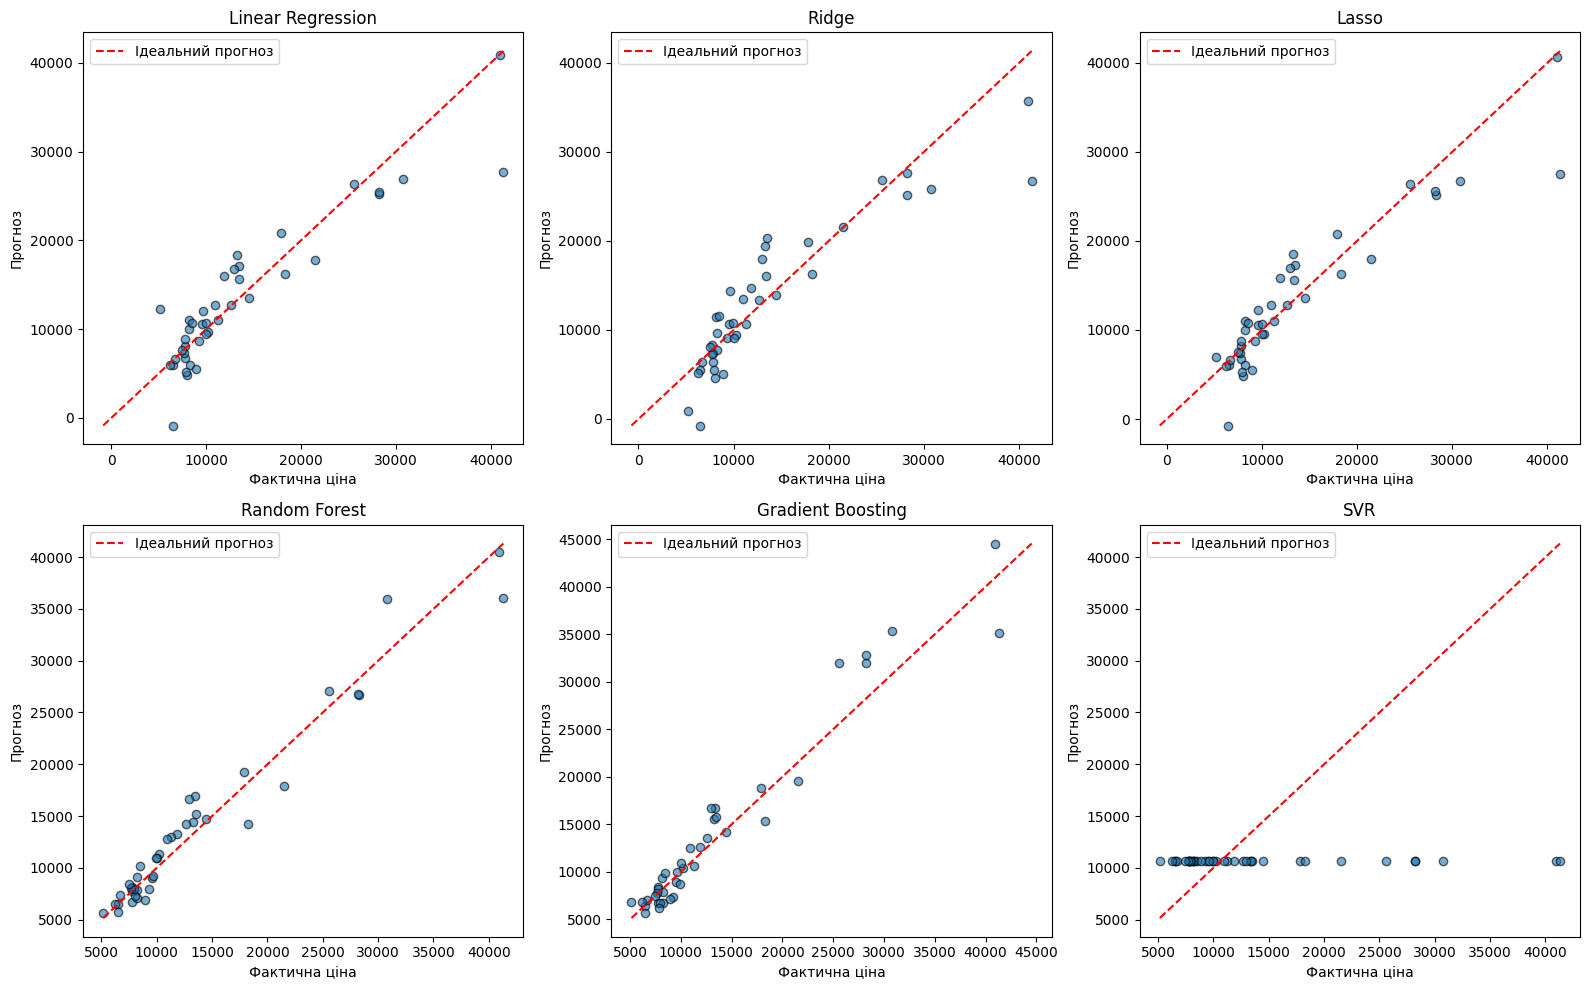

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, (name, pipe) in enumerate(models.items()):
    y_pred = pipe.predict(X_test)
    axes[i].scatter(y_test, y_pred, alpha=0.6, edgecolor='k')
    # лінія ідеального прогнозу
    lims = [min(y_test.min(), y_pred.min()),
            max(y_test.max(), y_pred.max())]
    axes[i].plot(lims, lims, 'r--', lw=1.5, label='Ідеальний прогноз')
    axes[i].set_title(name)
    axes[i].set_xlabel('Фактична ціна')
    axes[i].set_ylabel('Прогноз')
    axes[i].legend()

plt.tight_layout()
plt.show()

Для більшості моделей точки групуються вздовж лінії в діапазоні цін до ~25 000, але для дорогих автомобілів (понад 30 000) спостерігається помітне відхилення. Найкращу відповідність лінії демонструють Random Forest і Gradient Boosting — їхні точки найщільніше прилягають до ідеальної прямої.

## 14. Прогноз для 10 автомобілів

Випадково вибрати 10 автомобілів із тестової вибірки.

За допомогою моделі Random Forest отримати для них прогноз ціни та сформувати таблицю з такими даними:
- `car_ID`;
- фактична ціна;
- прогнозована ціна;
- абсолютна помилка;
- абсолютна відсоткова помилка.

Прокоментувати отримані результати.


In [ ]:
# Випадкові 10 авто з test
rng = np.random.default_rng(seed=42)
idx = rng.choice(len(X_test), size=10, replace=False)

# прогнозована ціна;
rf = models['Random Forest']
y_pred_10 = rf.predict(X_test.iloc[idx])

# car_ID, фактична ціна
y_true_10 = y_test.iloc[idx].values
car_ids_10 = ids_test.iloc[idx].values

# таблиця
result_table = pd.DataFrame({
    'car_ID':            car_ids_10,
    'Фактична ціна':     y_true_10,
    'Прогнозована ціна': y_pred_10.round(2),
    'Абсолютна помилка': np.abs(y_true_10 - y_pred_10).round(2),
    'Абс. відсотк. помилка, %':
        (np.abs(y_true_10 - y_pred_10) / y_true_10 * 100).round(2)
})

display(result_table)

,car_ID,Фактична ціна,Прогнозована ціна,Абсолютна помилка,"Абс. відсотк. помилка, %"
0,133,11850.0,13231.64,1381.64,11.66
1,17,41315.0,36096.48,5218.51,12.63
2,101,9549.0,9049.84,499.16,5.23
3,99,8249.0,7072.13,1176.87,14.27
4,153,6488.0,6497.00,9.00,0.14
5,70,28176.0,26804.29,1371.71,4.87
6,196,13415.0,16945.84,3530.83,26.32
7,147,7463.0,8416.78,953.78,12.78
8,148,10198.0,11369.76,1171.76,11.49
9,121,6229.0,6493.89,264.89,4.25


Модель Random Forest дала точні прогнози для 6 із 10 авто - відсоткова помилка менше 13%, а для car_ID = 153 вона становить лише 0.14%. Середня абсолютна помилка - близько 1600 доларів, середня відсоткова - ~11%. Найбільші відхилення спостерігаються для дорогих автомобілів (наприклад, car_ID = 17 з ціною 41 315) - модель їх недооцінює, що узгоджується з висновками завдань 11 і 13 і пояснюється малою кількістю дорогих авто в навчальній вибірці.

## 15. Висновки

Сформулювати підсумкові висновки за результатами роботи.

У висновках:
- порівняти якість усіх моделей;
- проаналізувати R², MAE, MSE і MAPE;
- зазначити, яка модель показала найкращі результати за отриманими метриками;
- прокоментувати величину похибок;
- звернути увагу на можливі ознаки перенавчання;
- коротко оцінити вплив попередньої обробки даних на результати моделювання.


1. Найкращі результати показали моделі Gradient Boosting і Random Forest (вони мають найвищий R2 та найнижчі MAE, MSE, MAPE) Лінійні моделі (Linear, Ridge, Lasso) продемонстрували трохи слабші, але стабільні результати. SVR виявився найслабшим.
2. Усі моделі мають додатний R2 на тесті, що підтверджує наявність реальної залежності між ознаками та ціною. Для найкращих моделей MAE ≈ 1500–2500 доларів, MAPE ≈ 10–13%. MSE помітно зростає через дорогі авто, на яких похибка найбільша.
3. Cеред R2, MAE, MSE і MAPE найкращою є Gradient Boosting (у деяких запусках і Random Forest). Обидві моделі дають найточніші прогнози та найменші похибки.
4. Для більшості автомобілів (середній ціновий діапазон 6000–30000) похибки прийнятні — 5–15%. Найбільші відхилення спостерігаються для дуже дорогих (>30 000) і дуже дешевих (<6000) авто – моделі схильні недооцінювати дорогі та переоцінювати дешеві (з завд. 13)
5. Лінійні моделі (Linear, Ridge, Lasso) мають близькі R2 на train і test – перенавчання відсутнє. Ансамблеві (Random Forest, Gradient Boosting) демонструють вищий R2 train, ніж test — це помірне перенавчання. SVR має найменший розрив, але й найнижчий R2 загалом.
6. Попередня обробка суттєво покращила якість моделей:
- Clipping викидів зменшив вплив екстремальних значень, особливо на SVR і лінійні моделі.
- Yeo–Johnson знизив асиметрію всіх неперервних ознак
- StandardScaler забезпечив коректну роботу Ridge, Lasso та SVR.
- видалення 4 ознак зменшило мультиколінеарність і стабілізувало коефіцієнти.
- One-Hot із handle_unknown='ignore' коректно обробив нові категорії в test.
- Видалення CarName запобігло проблеми високої розмірності та перенавчанню.

## Загальні вимоги до виконання

- Не використовувати тестову вибірку для визначення меж викидів, кореляційного відбору ознак, навчання трансформерів, масштабування або кодування категорій.
- Усі параметри передобробки мають визначатися тільки за навчальною вибіркою.
- Фінальні метрики моделей обчислювати на тестовій вибірці.
- Не використовувати `car_ID` як предиктор.
- Не видаляти спостереження або ознаки без пояснення причини.
- До кожного основного етапу додати короткий змістовний висновок.
- У підсумкових висновках спиратися на отримані метрики та графіки.
